### Time to get your hands dirty. Galaxy vs quasars

We're now going to classify galaxy vs quasars in the Sloan Digital Sky Survey. 

This is one of the most famous example of machine-learning classification in astronomy. For some recent work see e.g. 
- *Identifying galaxies, quasars, and stars with machine learning: A new catalogue of classifications for 111 million SDSS sources without spectra* Clarke et al (2019) [arXiv:1909.10963](https://arxiv.org/abs/1909.10963)
- *Quasar and galaxy classification in Gaia Data Release 2* Bailer-Jones et al (2019) [arXiv:1910.05255](https://arxiv.org/abs/1910.05255)

Some figures from the second paper:


SDSS observed in four bands:
    
![](https://speclite.readthedocs.io/en/latest/_images/sdss2010.png) 
    

#### Data

The dataset is at `solutions/galaxyquasar.csv`. I have extracted it myself from the SDSS database using the SQL query reported [here](https://www.astroml.org/_modules/astroML/datasets/sdss_galaxy_colors.html#fetch_sdss_galaxy_colors)

(If you've never used [SQL](https://en.wikipedia.org/wiki/SQL) and want to learn something new it's computing, it's very powerful)

#### Tasks

- Create arrays for the $(u-g)$, $(g-r)$, $(r-i)$, and $(i-z)$ colors. Also create an array with the class labels where galaxy=$0$ and quasar=$1$. 
- Classify the dataset against the target label.
- Try some of the classification methods we've seen so far and evaluate the performance using the ROC curve.
- Remember to split the dataset into training and validation...

#### Ideas
- Try using different colors (a subset of them first, than all together). Which is the most important feature?
- What are the colors that better satisfy or invalidate the "Naive" assumption of independence between the attributes?


In [110]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline
%config InlineBackend.figure_format='retina'


In [111]:
#loading data
data = pd.read_csv("/Users/albertodufour/code/astrostatistics_bicocca_2025/solutions/galaxyquasar.csv")

# data.info()
# data.head()
# data.tail()
# data.describe()
# data.columns
# data.index
# data.isnull().sum()
# data.dtypes
data

,u,g,r,i,z,class,z1,zerr
0,18.97213,18.53676,18.58280,18.34936,18.29215,QSO,0.522819,0.000155
1,19.24592,17.47646,16.47817,16.04472,15.68851,GALAXY,0.122846,0.000028
2,19.43536,17.70268,16.91565,16.58327,16.39128,GALAXY,0.000000,0.000000
3,19.31626,18.18312,17.39591,16.94549,16.65395,GALAXY,0.147435,0.000009
4,19.28828,19.11188,18.88937,18.80013,18.49183,QSO,2.011455,0.000631
...,...,...,...,...,...,...,...,...
49995,19.37295,18.12382,17.39886,16.98503,16.70585,GALAXY,0.113016,0.000011
49996,18.52021,16.88262,16.03280,15.56884,15.22454,GALAXY,0.085063,0.000014
49997,18.62718,17.30876,16.87371,16.62399,16.42296,GALAXY,0.054429,0.000008
49998,19.55140,18.27711,17.62101,17.21947,17.03347,GALAXY,0.112571,0.000009


In [112]:
ug = data["u"] - data["g"]
gr = data["g"] - data["r"]
ri = data["r"] - data["i"]
iz = data["i"] - data["z"]


In [116]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
# Assign galaxy=0, quasar=1
data['class'] = le.fit_transform(data['class'])
labels = le.inverse_transform(data['class'])

# **NAIVE BAYES**

In [117]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split

X = np.column_stack([ug, gr, ri, iz])
y = labels
print(X[:,1])
#splitting into train and test
test_size = 0.4
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)

#fitting
gnb = GaussianNB()
gnb.fit(X_train,y_train)

#testing performance
y_pred = gnb.predict(X_test)
y_prob = gnb.predict_proba(X_test)[:, 1]

[-0.04604  0.99829  0.78703 ...  0.43505  0.6561   0.35251]


In [118]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_curve, precision_recall_curve

fpr, tpr, thresholds = roc_curve(y_test, y_pred)
precision, recall, pr_thresh = precision_recall_curve(y_test, y_prob)

print(fpr, tpr, thresholds)

print("accuracy:", accuracy_score(y_test, y_pred))
print("precision:", precision_score(y_test, y_pred))
print("recall:", recall_score(y_test, y_pred))

[0.         0.01651494 1.        ] [0.         0.92493017 1.        ] [inf  1.  0.]
accuracy: 0.9751
precision: 0.9034788540245566
recall: 0.9249301675977654


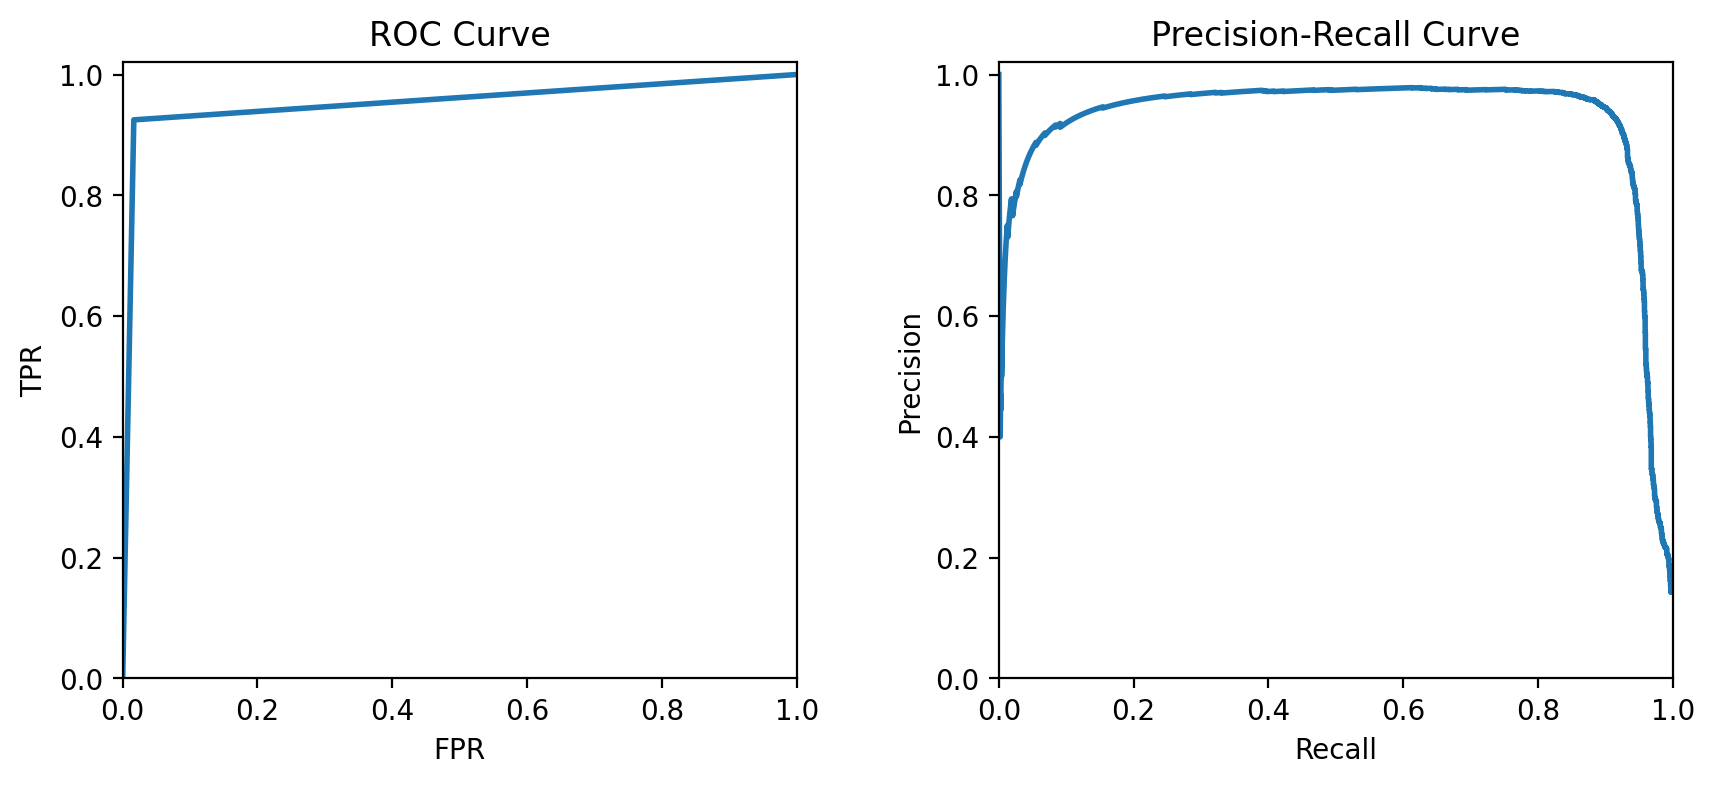

Accuracy : 0.9751
Precision: 0.9034788540245566
Recall   : 0.9249301675977654


In [121]:
# ---------- PLOTTING -----------
fig = plt.figure(figsize=(10, 4))
fig.subplots_adjust(wspace=0.3)

ax1 = plt.subplot(121)
ax2 = plt.subplot(122)

# --- ROC ---
ax1.plot(fpr, tpr, lw=2)
ax1.set_xlabel("FPR")
ax1.set_ylabel("TPR")
ax1.set_title("ROC Curve")
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1.02)

# --- Precision–Recall ---
ax2.plot(recall, precision, lw=2)
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.set_title("Precision-Recall Curve")
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1.02)

plt.show()

# ----------  PRINTING ----------------
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))

## **SINGLE COLOURS**

In [130]:
#----------- Imports --------
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    roc_curve, precision_recall_curve
)

#----------- Storage lists --------
y_preds = []
y_probs = []
fprs = []
tprs = []
roc_thresholds = []

precisions_list = []
recalls_list = []
pr_thresholds_list = []

#----------- Loop through each feature (ug, gr, ri, iz) --------
for i in range(4):

    #----------- Extract single feature column --------
    x = X[:, i].reshape(-1, 1)   # make it 2D for sklearn

    #----------- Train-test split --------
    X_train, X_test, y_train, y_test = train_test_split(
        x, y, test_size=0.4, random_state=42
    )

    #----------- Fit Gaussian Naive Bayes --------
    gnb = GaussianNB()
    gnb.fit(X_train, y_train)

    #----------- Predict class labels & probabilities --------
    y_pred = gnb.predict(X_test)
    y_prob = gnb.predict_proba(X_test)[:, 1]

    y_preds.append(y_pred)
    y_probs.append(y_prob)

    #----------- ROC curve (use probabilities!) --------
    fpr, tpr, roc_thresh = roc_curve(y_test, y_prob)

    fprs.append(fpr)
    tprs.append(tpr)
    roc_thresholds.append(roc_thresh)

    #----------- Precision-recall curve --------
    precision, recall, pr_thresh = precision_recall_curve(y_test, y_prob)

    precisions_list.append(precision)
    recalls_list.append(recall)
    pr_thresholds_list.append(pr_thresh)



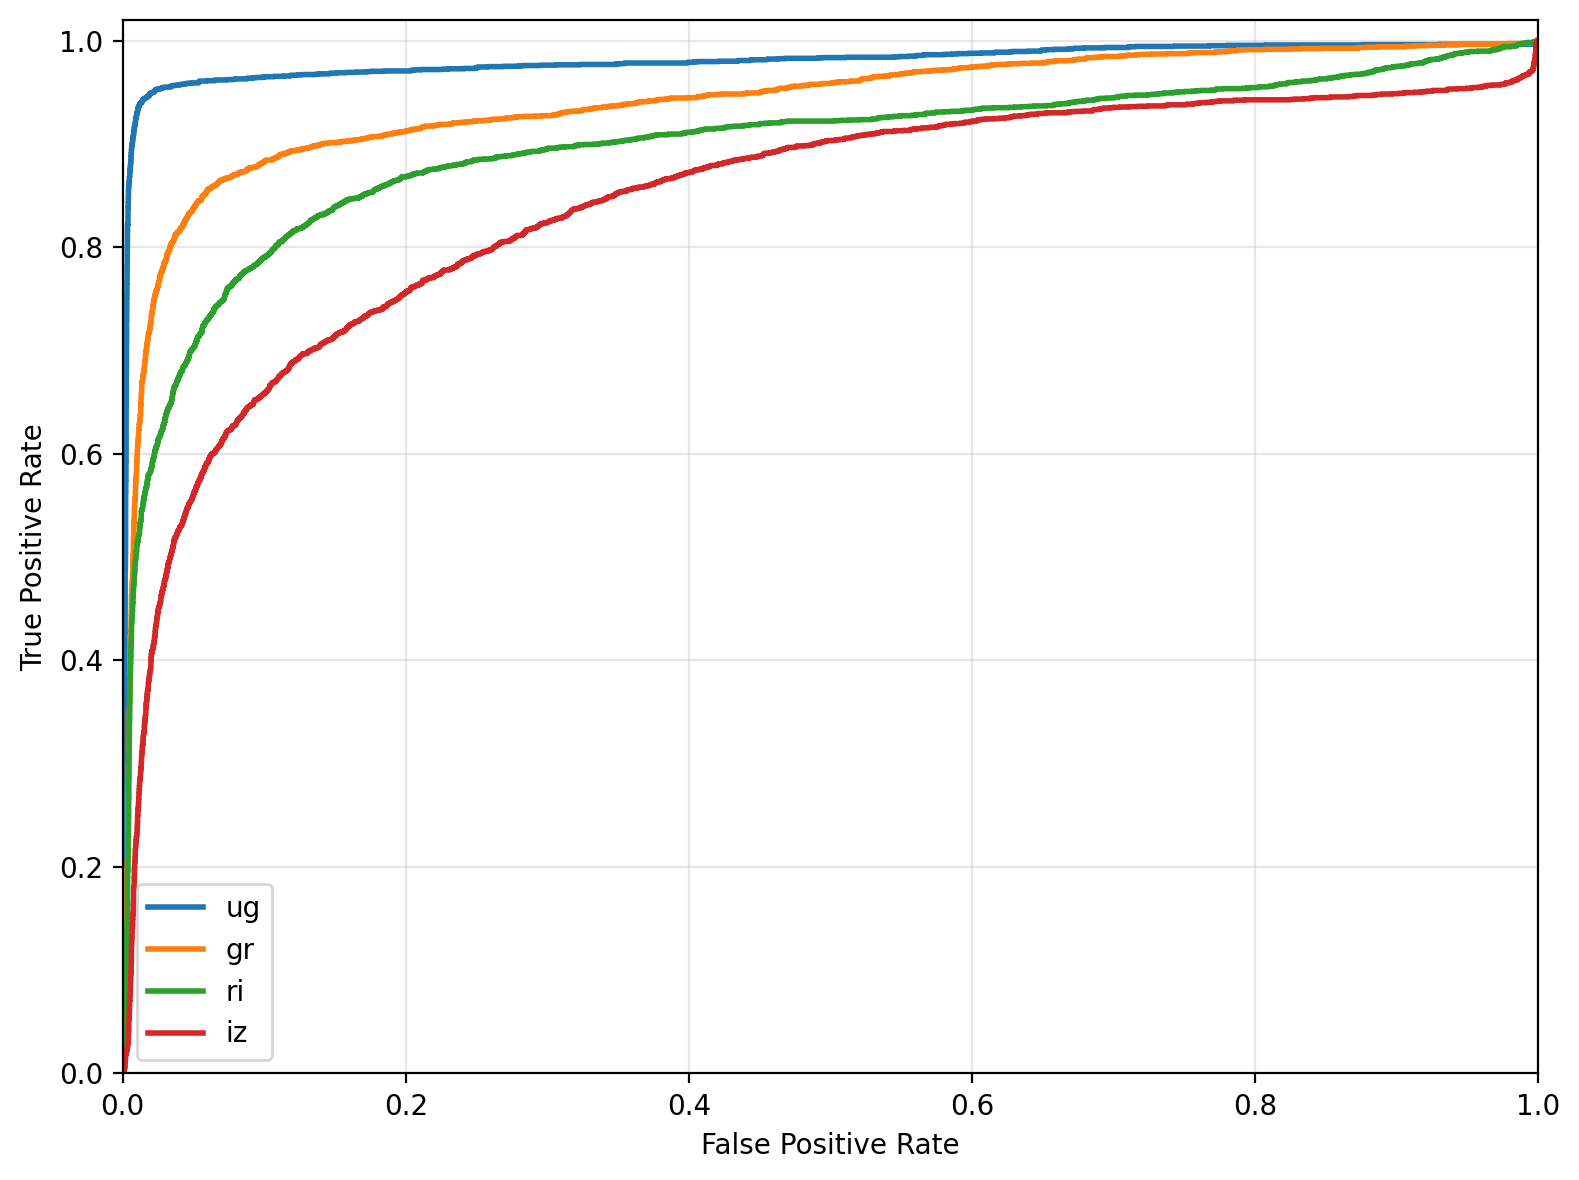

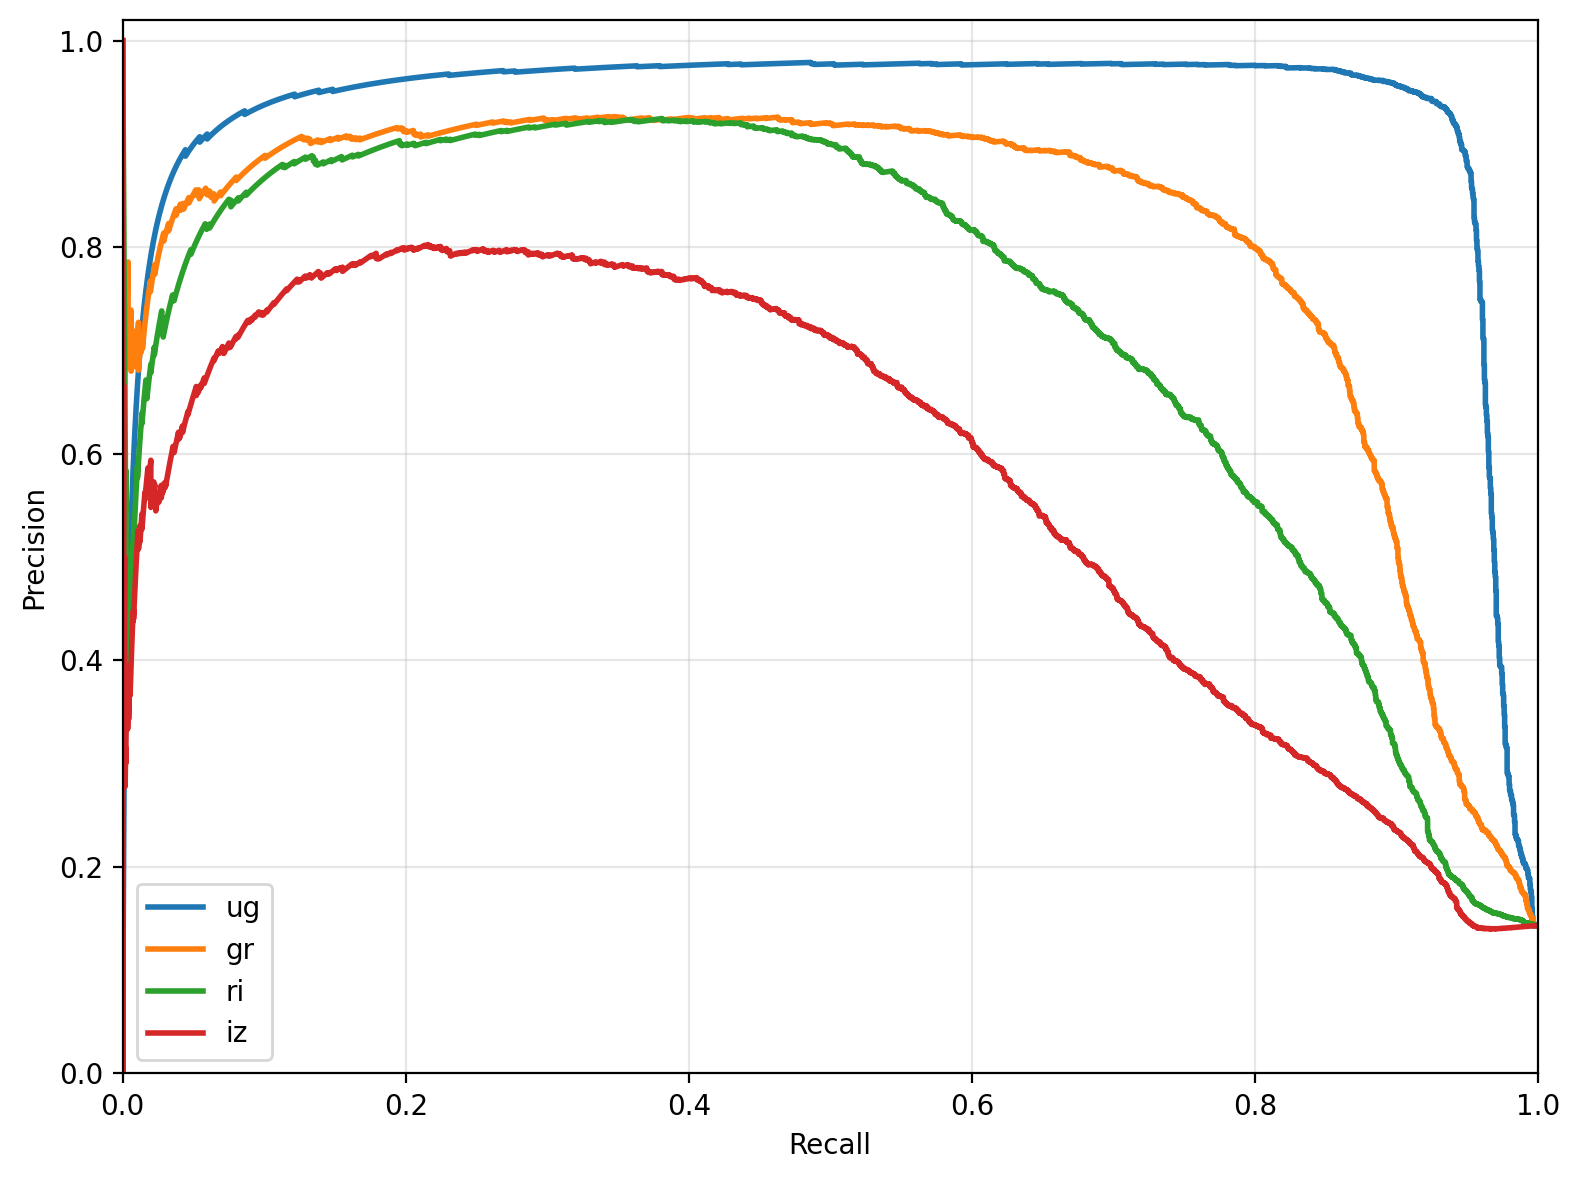

In [134]:
#----------- Feature names for plotting --------
feature_names = ["ug", "gr", "ri", "iz"]

#----------- ROC Curve Plot --------
plt.figure(figsize=(8, 6))

for i in range(4):
    plt.plot(fprs[i], tprs[i], lw=2, label=f"{feature_names[i]}")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.xlim(0, 1)
plt.ylim(0, 1.02)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

#----------- Precision–Recall Curve Plot --------
plt.figure(figsize=(8, 6))

for i in range(4):
    plt.plot(recalls_list[i], precisions_list[i], lw=2, label=f"{feature_names[i]}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.xlim(0, 1)
plt.ylim(0, 1.02)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


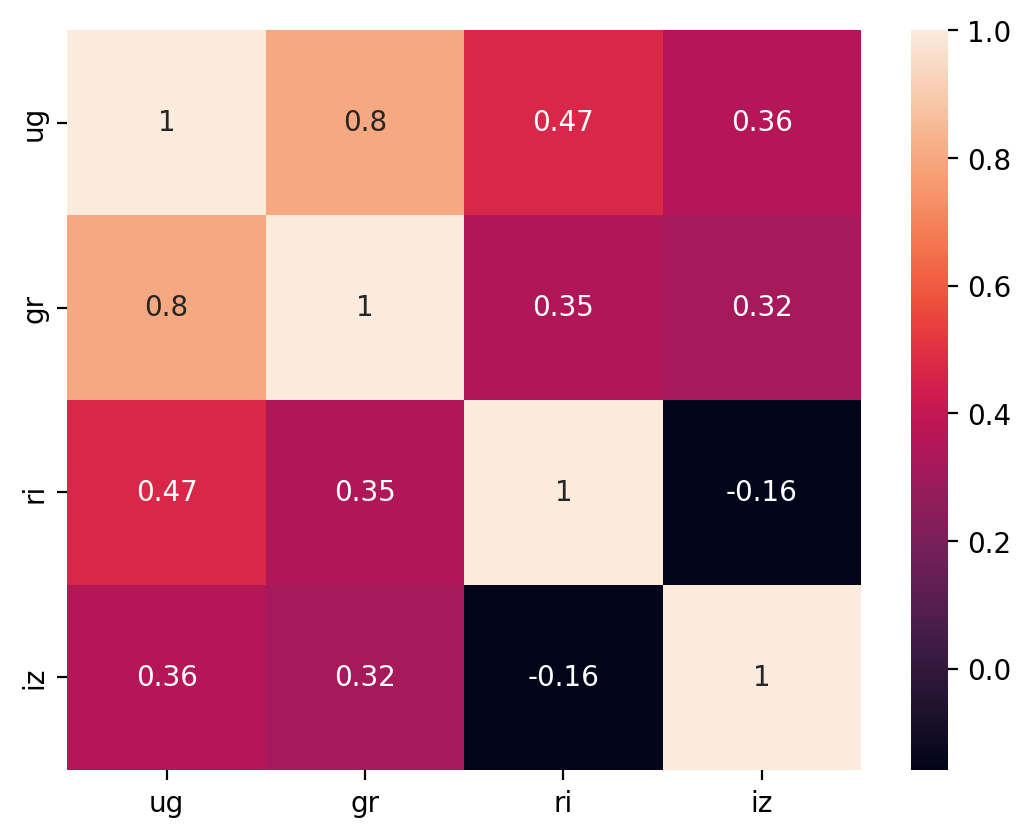

[[ 1.          0.80331471  0.46923704  0.36033523]
 [ 0.80331471  1.          0.34771217  0.31845435]
 [ 0.46923704  0.34771217  1.         -0.15812775]
 [ 0.36033523  0.31845435 -0.15812775  1.        ]]


In [138]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = np.corrcoef(X.T)
sns.heatmap(corr, annot=True, xticklabels=feature_names, yticklabels=feature_names)
plt.show()

print(corr)



worst (ug,gr) pair:
Accuracy : 0.9762
Precision: 0.9080656185919344
Recall   : 0.9277234636871509

best (ri,iz) pair:
Accuracy : 0.8748
Precision: 0.8947368421052632
Recall   : 0.1424581005586592


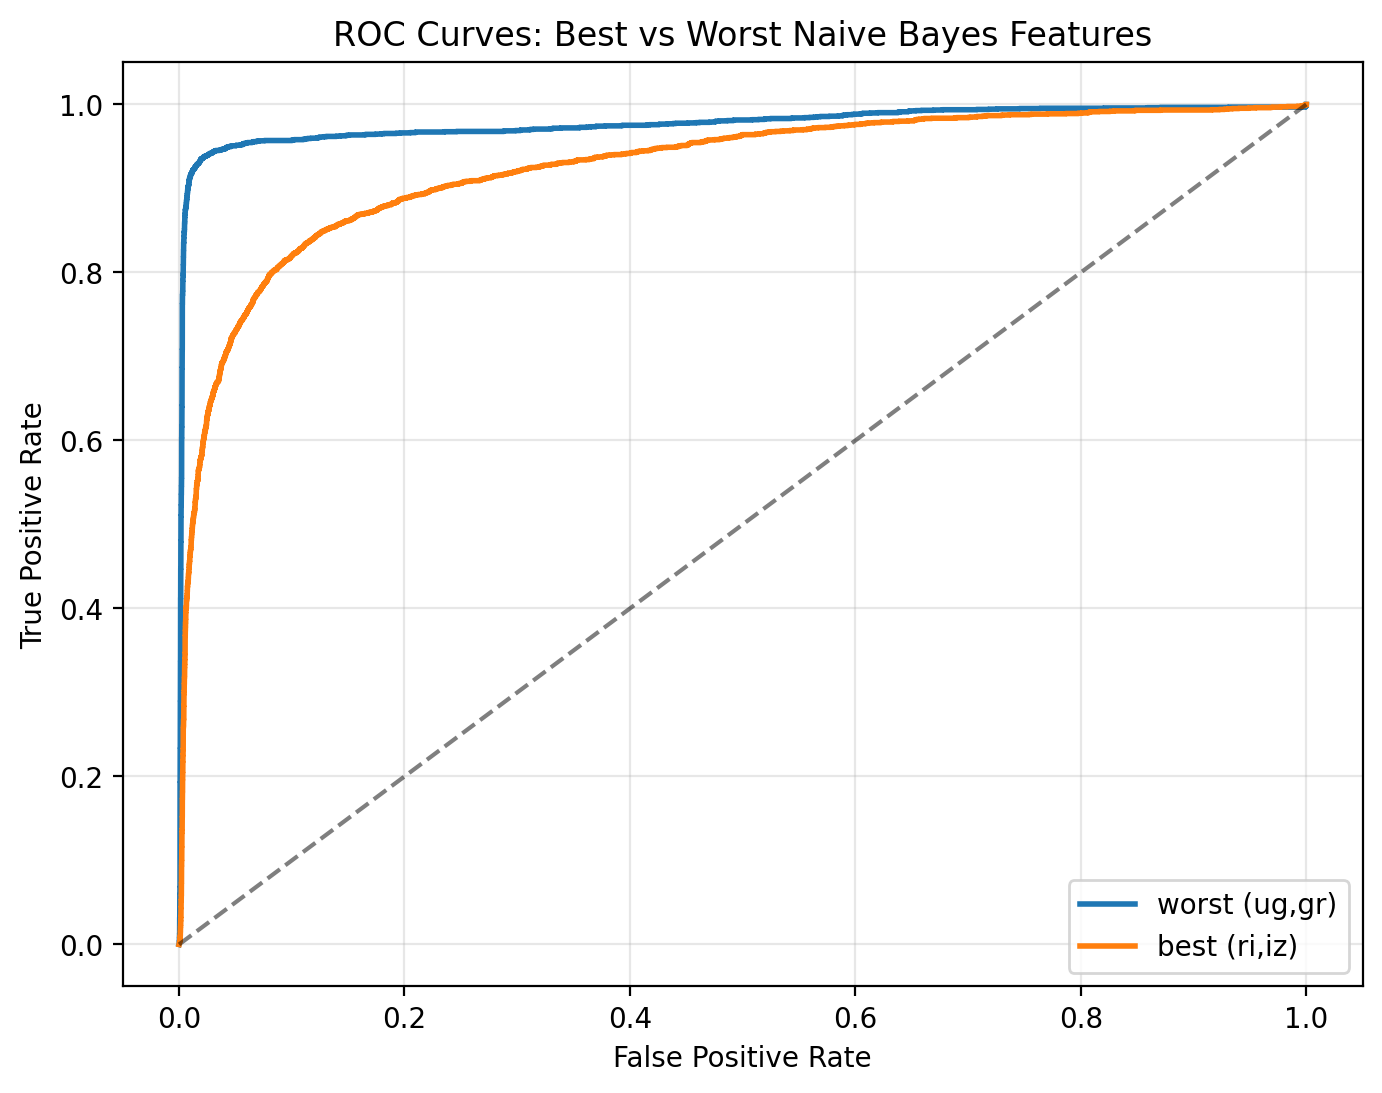

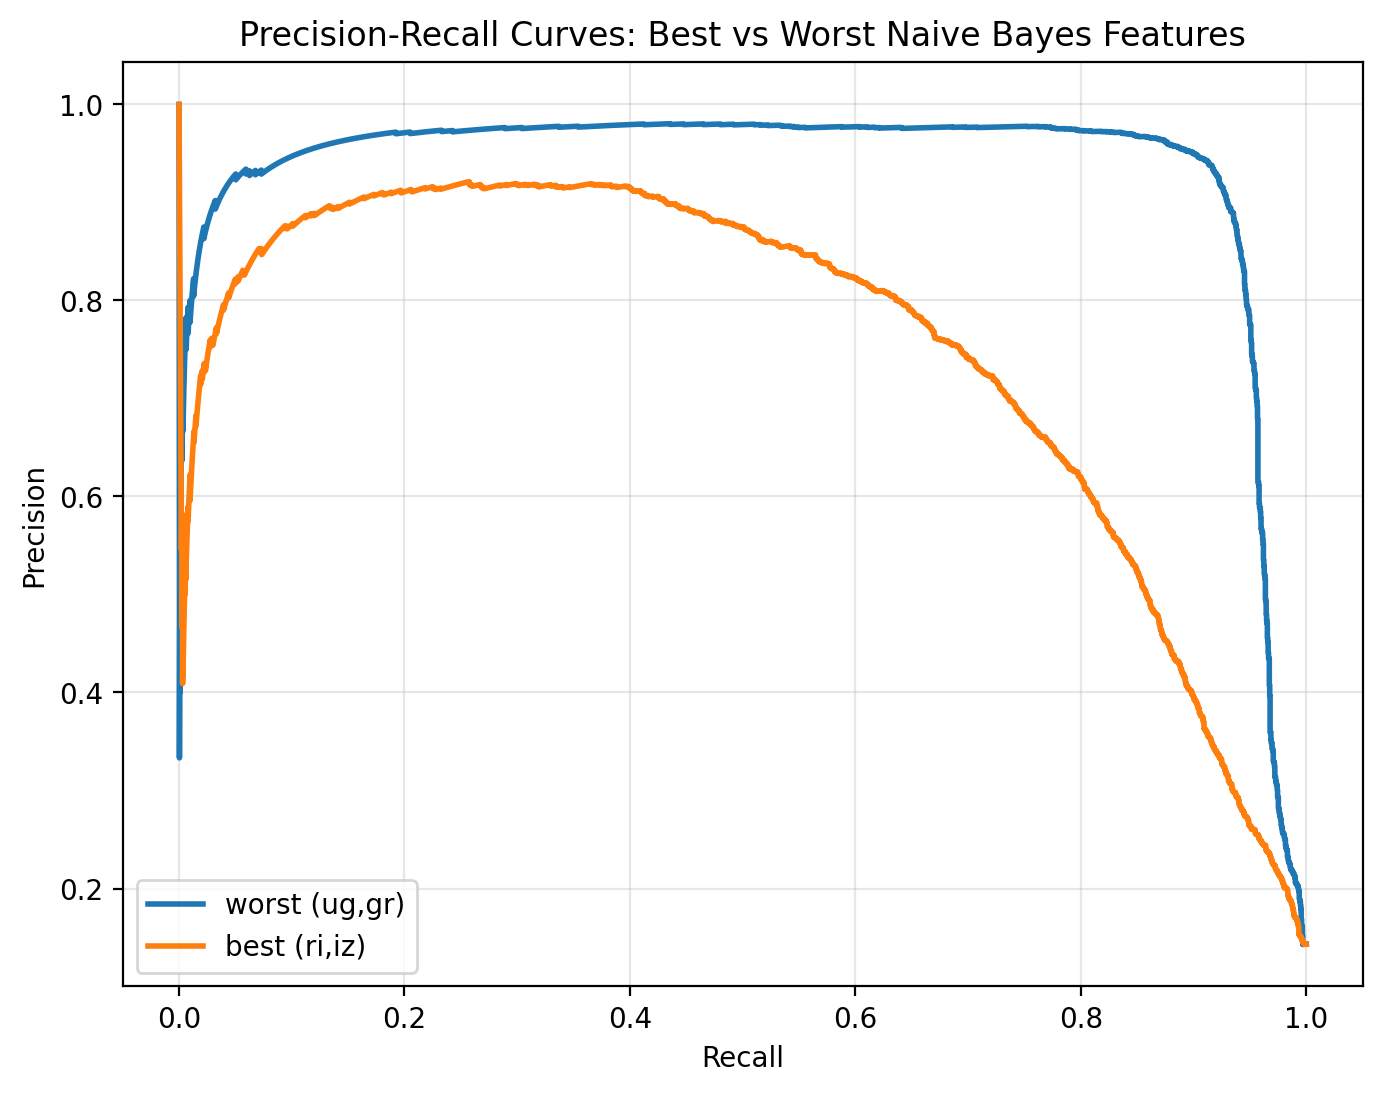

In [139]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, precision_recall_curve, accuracy_score, precision_score, recall_score

#----------- Feature indices --------
# worst: ug & gr -> indices 0,1
# best: ri & iz -> indices 2,3
feature_pairs = {
    "worst (ug,gr)": [0, 1],
    "best (ri,iz)": [2, 3]
}

#----------- Storage for curves --------
fprs = {}
tprs = {}
precisions_list = {}
recalls_list = {}

#----------- Loop over the two pairs --------
for name, cols in feature_pairs.items():
    X_pair = X[:, cols]  # select 2 features
    
    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_pair, y, test_size=0.4, random_state=42
    )
    
    # Fit Gaussian NB
    gnb = GaussianNB()
    gnb.fit(X_train, y_train)
    
    # Predict probabilities
    y_prob = gnb.predict_proba(X_test)[:, 1]
    y_pred = gnb.predict(X_test)
    
    # Compute ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    fprs[name] = fpr
    tprs[name] = tpr
    
    # Compute Precision-Recall
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    precisions_list[name] = precision
    recalls_list[name] = recall
    
    # Print basic metrics
    print(f"\n{name} pair:")
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))

#----------- Plot ROC curves --------
plt.figure(figsize=(8,6))
for name in feature_pairs:
    plt.plot(fprs[name], tprs[name], lw=2, label=name)
plt.plot([0,1],[0,1],'k--', alpha=0.5)  # random line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves: Best vs Worst Naive Bayes Features")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#----------- Plot Precision-Recall curves --------
plt.figure(figsize=(8,6))
for name in feature_pairs:
    plt.plot(recalls_list[name], precisions_list[name], lw=2, label=name)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves: Best vs Worst Naive Bayes Features")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


<mark> COUNTER INTUITIVE!! </mark>